In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import plotly.graph_objects as go


plt.style.use("default")
plt.rcParams["figure.figsize"] = (15,6)
matplotlib.rcParams['axes.labelsize'] = 14
matplotlib.rcParams['xtick.labelsize'] = 12
matplotlib.rcParams['ytick.labelsize'] = 12
matplotlib.rcParams['text.color'] = 'k'

# Loading data

In [2]:
train_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_sequences.csv"
)
train_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/train_labels.csv"
)
validation_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_sequences.csv"
)
validation_labels = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/validation_labels.csv"
)

test_sequence = pd.read_csv(
    "C:/Users/Admin/Downloads/stanford-rna-3d-folding-2/test_sequences.csv"
)



C:\Users\Admin\AppData\Local\Temp\ipykernel_26852\77482081.py:4: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  train_labels = pd.read_csv(


In [3]:
train_sequence.head()

,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES
0,4TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1978-04-12,FURTHER REFINEMENT OF THE STRUCTURE OF YEAST T...,A:1,>4TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
1,6TNA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1979-01-16,CRYSTAL STRUCTURE OF YEAST PHENYLALANINE T-RNA...,A:1,>6TNA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
2,1TRA,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-07-14,RESTRAINED REFINEMENT OF THE MONOCLINIC FORM O...,A:1,>1TRA_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG,[Mg+2]
3,1TN2,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1986-10-24,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN2_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN
4,1TN1,GCGGAUUUAGCUCAGUUGGGAGAGCGCCAGACUGAAGAUCUGGAGG...,1987-01-15,CRYSTALLOGRAPHIC AND BIOCHEMICAL INVESTIGATION...,A:1,>1TN1_1|Chain A[auth A]|TRNAPHE|\nGCGGAUUUAGCU...,MG;PB;SPM,[Mg+2];[Pb+2];C(CCNCCCN)CNCCCN


In [4]:
train_labels.head()

,ID,resname,resid,x_1,y_1,z_1,chain,copy
0,157D_1,C,1,4.843,-5.640,13.265,A,1
1,157D_2,G,2,3.385,-7.613,8.267,A,1
2,157D_3,C,3,2.158,-6.751,2.949,A,1
3,157D_4,G,4,2.669,-4.843,-1.773,A,1
4,157D_5,A,5,3.509,0.239,-4.045,A,1


In [5]:
print("number of unique target IDs which are pdb_id_chain_id", train_sequence["target_id"].nunique())

number of unique target IDs which are pdb_id_chain_id 5716


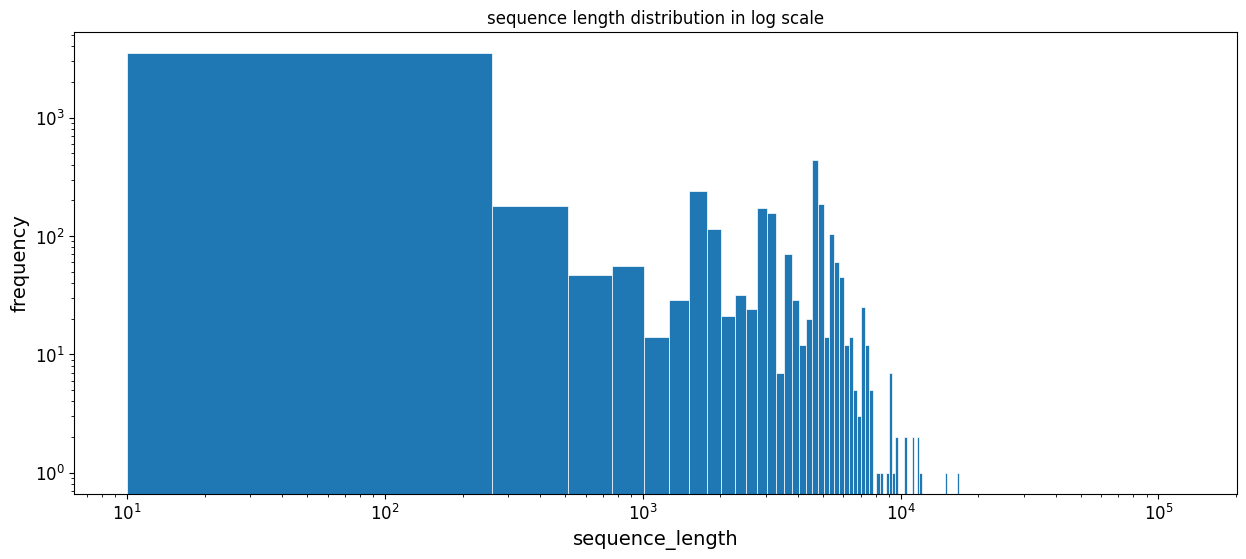

In [6]:
# distribution of sequence lengths:

train_sequence["len_sequence"] = train_sequence["sequence"].str.len()

fig, ax = plt.subplots()

ax.hist(train_sequence["len_sequence"], bins=500, linewidth=0.5, edgecolor="white")
ax.set_yscale('log', base=10)
ax.set_xscale('log', base=10)
plt.xlabel("sequence_length")
plt.ylabel("frequency")
plt.title("sequence length distribution in log scale")
plt.show()


In [7]:
train_labels[["split_ID", "suffix"]] = train_labels["ID"].str.split('_', expand=True)

In [8]:
# plotting some target examples
unique_ids = train_labels["split_ID"].unique()
for target_id in unique_ids[:1]:
    # target_id = train_labels["ID"].iloc[i].split("_")[0]
    sub = train_labels[train_labels["ID"].str.startswith(target_id)]

    x = sub["x_1"].values
    y = sub["y_1"].values
    z = sub["z_1"].values


    fig = go.Figure(
        data=[go.Scatter3d(
            x=x, y=y, z=z,
            mode="lines+markers",
            marker=dict(size=3),
            line=dict(width=2)
        )]
    )

    fig.update_layout(
        title=f"RNA structure: {target_id}",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z"
        )
    )

    fig.show()



In [11]:

lengths = train_sequence["sequence"].str.len()

print("sequence length percentiles:", np.percentile(lengths, [50, 75, 90, 95, 99]))

sequence length percentiles: [  94.5  2583.75 4751.   5348.   7230.6 ]


In [13]:
# Reducing long sequences examples for initial model run

filtered_train_sequence = train_sequence[train_sequence["sequence"].str.len() <2500]